# Healthcare Accessibility Analysis in Northern Ireland

This notebook calculates the distance from Data Zones to the nearest hospital
and estimates the population living more than 20 km from healthcare services.

In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt

from analysis import load_and_merge_datazones

## 1. Load Data Zone boundaries and population data

In [2]:
# Load Data Zone boundaries and merge with Census population data
dz = load_and_merge_datazones(
    "data/DZ2021.shp",
    "data/census-2021-ms-a01.xlsx"
)

## 2. Resident population by Data Zone

This map provides population context for the study area.  These population counts are later used to estimate how many residents live in Data Zones with poor hospital accessibility.

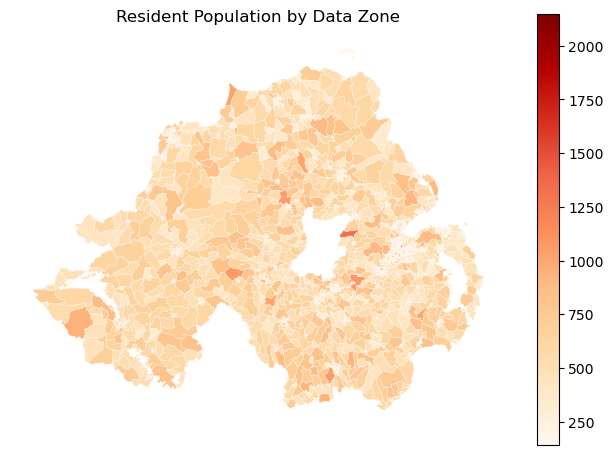

In [3]:
# Plot resident population by Data Zone to provide context for accessibility analysis
fig, ax = plt.subplots(figsize=(8, 8))

dz.plot(
    column="All usual residents",
    cmap="OrRd",
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.2,
    legend_kwds={"shrink": 0.7}
)

ax.set_title("Resident Population by Data Zone")
ax.axis("off")

plt.show()

## 3. Prepare the study area for OpenStreetMap query

In [4]:
# Reproject Data Zones to WGS84 and get bounding box for OSM hospital query
dz_wgs84 = dz.to_crs("EPSG:4326")
bbox = dz_wgs84.total_bounds

## 4. Retrieve hospital locations from OpenStreetMap

In [5]:
# Retrieve hospital locations from OpenStreetMap within the study area
hospitals = ox.features_from_bbox(
    bbox,
    tags={"amenity": "hospital"}
)

## 5. Clean hospital geometries

In [6]:
# Keep only point and polygon hospital geometries
hospitals = hospitals[hospitals.geometry.type.isin(["Point", "Polygon", "MultiPolygon"])]

In [7]:
# Convert hospital geometries to representative points
hospitals["hospital_point"] = hospitals.geometry.representative_point()
hospitals = hospitals.set_geometry("hospital_point")

In [8]:
# Reproject hospitals to match Data Zone CRS
hospitals = hospitals.to_crs(dz.crs)

In [9]:
# Keep only hospitals located within the Northern Ireland study area.
# 'intersects' is used instead of 'within' to avoid excluding boundary cases.
hospitals = hospitals[hospitals.intersects(dz.union_all())]

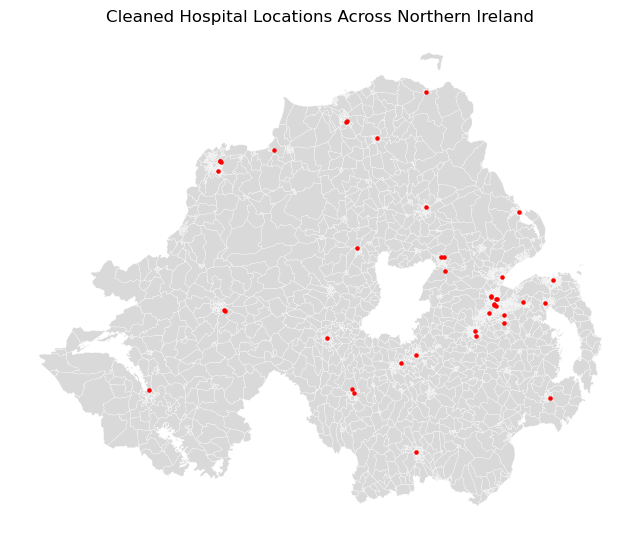

In [10]:
# Plot cleaned hospital locations for visual verification
fig, ax = plt.subplots(figsize=(8, 8))

dz.plot(
    color="#d9d9d9",
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

hospitals.plot(ax=ax, color="red", markersize=5)

ax.set_title("Cleaned Hospital Locations Across Northern Ireland")
ax.axis("off")

plt.show()

## 6. Calculate distance to nearest hospital

Distance is calculated from a representative point within each Data Zone to the nearest hospital location. This provides a simplified measure of spatial accessibility based on straight-line distance rather than road network travel time.

In [11]:
# Create a representative point for each Data Zone polygon
dz["zone_point"] = dz.geometry.representative_point()

# Create a point-based version of the Data Zones for distance calculation
dz_points = dz.copy()
dz_points = dz_points.set_geometry("zone_point")

# Calculate distance to nearest hospital
distances = []

for point in dz_points.geometry:
    nearest_distance = hospitals.distance(point).min()
    distances.append(nearest_distance)

dz["nearest_hospital_m"] = distances

In [12]:
# Convert nearest hospital distance from metres to kilometres
dz["nearest_hospital_km"] = dz["nearest_hospital_m"] / 1000

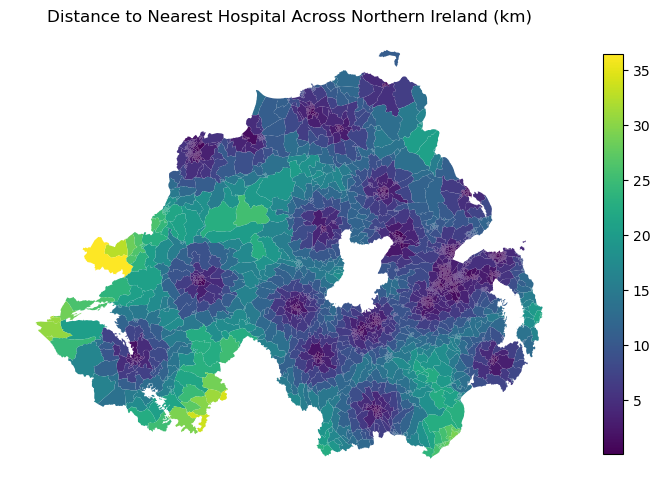

In [13]:
# Plot distance to nearest hospital (km) across Northern Ireland
fig, ax = plt.subplots(figsize=(9, 8))

dz.plot(
    column="nearest_hospital_km",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="none",
    linewidth=0,
    legend_kwds={"shrink": 0.65}
)

ax.set_title("Distance to Nearest Hospital Across Northern Ireland (km)")
ax.axis("off")

plt.show()

### Interpretation

Darker colours represent Data Zones located closer to hospital facilities, while greener and yellow tones indicate increasing distance to the nearest hospital.

The map shows clusters of lower-distance Data Zones around hospital locations, with distance generally increasing across more remote and rural parts of Northern Ireland.  Small variations between neighbouring zones reflect the fact that distance is calculated separately for each Data Zone rather than as a continuous surface.

## 7. Identify populations with poor access

In [14]:
# Identify Data Zones where the nearest hospital is more than 20 km away,
# and estimate the affected population by summing residents in those areas
dz["population_far"] = dz["All usual residents"] * (dz["nearest_hospital_km"] > 20)

In [15]:
# Calculate the total population living more than 20 km from a hospital
total_population_far = dz["population_far"].sum()

print(f"Total population living more than 20 km from a hospital: {total_population_far:,.0f}")

Total population living more than 20 km from a hospital: 77,299


## 8. Visualise accessibility outcomes

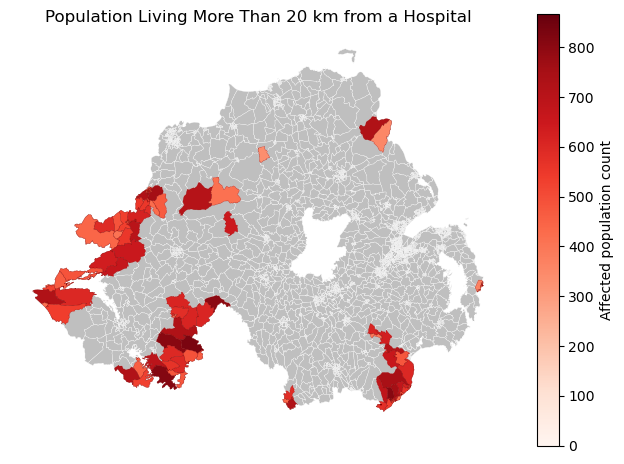

In [16]:
# Highlight Data Zones where resident population lives more than 20 km from the nearest hospital
fig, ax = plt.subplots(figsize=(8, 8))

# Base map showing all Data Zones for geographic context
dz.plot(
    color="#bfbfbf",
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

# Overlay only Data Zones with affected population
dz[dz["population_far"] > 0].plot(
    column="population_far",
    cmap="Reds",
    vmin=0,
    legend=True,
    ax=ax,
    edgecolor="darkred",
    linewidth=0.2,
    legend_kwds={
        "label": "Affected population count",
        "shrink": 0.7
    }
)

ax.set_title("Population Living More Than 20 km from a Hospital")
ax.axis("off")

plt.show()

### Interpretation

This map highlights only those Data Zones where residents live more than 20 km from the nearest hospital.  The concentration of affected populations in the west, south-west and a smaller number of peripheral locations elsewhere indicates a clear spatial unevenness in hospital accessibility across Northern Ireland.

The use of a neutral base layer ensures that unaffected Data Zones remain visible for geographic context, while the red overlay highlights areas where poor accessibility coincides with resident population.

These spatial patterns correspond to an estimated 77,000 residents living more than 20 km from a hospital, highlighting the scale of accessibility inequality across the region.